### Prueba tecnica - Subocol IA (Especialista IA)

El objetivo de esta prueba es evaluar sus habilidades en el ciclo de vida de un proyecto de Inteligencia Artificial, centrándose en dos pilares fundamentales:

1.	Modelamiento: Diseño y entrenamiento de un modelo de clasificación.
2.	Despliegue: Creación de un servicio de inferencia para el consumo del modelo.

Acorde al PDF adjunto lea detenidamente y complete con el codigo necesario el desarollo de la prueba en este notebook, si requiere utilizar scripts adicionales para desplegar el servicio y el modelo, lo puede hacer. 

La idea de este notebook es verificar el tratamiento de los datos y el entrenamiento del modelo. 

In [1]:
import re

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

### Explicacion de las columnas

- numero_aviso: id numerico del aviso (numero del incidente/siniestro).
- fecha_creacion: Fecha de creacion del aviso.
- tipo_carroceria: Tipo de carrocería del vehículo (ej: hatchback, sedán, SUV, etc.).
- marca: Fabricante del vehículo (ej: HYUNDAI).
- linea: Linea del vehículo (ej: GRAND I10 HB).
- version:	Variante específica de la linea, (ej: 1400 CC SEDAN).
- modelo: Año de fabricación del vehículo (ej: 2020).
- version_hechos: Descripción del incidente/aviso ocurrido (ej: "iba en la vía, me colisionan a un costado y le...").
- codigo_irs: Código identificador de la pieza/repuesto (ej: 06040006nddn).
- nombre_irs: Nombre descriptivo de la pieza afectada (ej: "rin sencillo delantero derecho", "cubre polvo...").
- piezas_totales: Cantidad total de piezas involucradas en el aviso.
- piezas_cambio: Cantidad de piezas que requieren cambio/reemplazo.
- estado_aviso: estado entregado u objetado

In [3]:
# Lectura dataset
version_piezas = pd.read_csv(
    r"C:\Users\juan_\Desktop\subocol-prueba\data\dataset_pt.csv",
    low_memory=False,
    sep=";",
)

In [4]:
version_piezas.head()

,numero_aviso,fecha_creacion,tipo_carroceria,marca,linea,version,modelo,version_hechos,codigo_irs,nombre_irs,piezas_totales,piezas_cambio,estado_aviso
0,237305,2025-01-03 10:10:18.421101,pickup,VOLKSWAGEN,AMAROK,POWER PLUS 4X4 2.0 AUT,2016,maquinaria motoniveladora me choco en reversa ...,02090112nndn,parachoque del.,13,13,ENTREGADO
1,237305,2025-01-03 10:10:18.421101,pickup,VOLKSWAGEN,AMAROK,POWER PLUS 4X4 2.0 AUT,2016,maquinaria motoniveladora me choco en reversa ...,02030014nnnn,broche carroceria,13,13,ENTREGADO
2,237305,2025-01-03 10:10:18.421101,pickup,VOLKSWAGEN,AMAROK,POWER PLUS 4X4 2.0 AUT,2016,maquinaria motoniveladora me choco en reversa ...,03040008nndn,ampolleta.,13,13,ENTREGADO
3,237305,2025-01-03 10:10:18.421101,pickup,VOLKSWAGEN,AMAROK,POWER PLUS 4X4 2.0 AUT,2016,maquinaria motoniveladora me choco en reversa ...,02090129nndn,mascara del. central,13,13,ENTREGADO
4,237305,2025-01-03 10:10:18.421101,pickup,VOLKSWAGEN,AMAROK,POWER PLUS 4X4 2.0 AUT,2016,maquinaria motoniveladora me choco en reversa ...,02010229nndn,tapa de neblinero delantero izquierdo,13,13,ENTREGADO


### Feature Engineering con limpieza de datos

Empezamos transformando el formato leído como un archivo CSV a un DataFrame para poder utilizar la biblioteca de Pandas y realizar el análisis de los datos.

In [5]:
df = version_piezas

Agrupamos por 'numero_aviso', la cual respecta a la variable objetivo.

In [6]:
df_grupo = (
    df.groupby("numero_aviso")
    .agg(
        {
            "fecha_creacion": "first",
            "tipo_carroceria": "first",
            "marca": "first",
            "linea": "first",
            "version": "first",
            "modelo": "first",
            "version_hechos": "first",
            "piezas_totales": "first",
            "piezas_cambio": "first",
            "estado_aviso": "first",
            "nombre_irs": lambda x: ", ".join(
                x.dropna().astype(str).unique()
            ),  # Listado de piezas
        }
    )
    .reset_index()
)

In [7]:
df_grupo.rename(columns={"nombre_irs": "piezas_afectadas"}, inplace=True)
print(f"Total de siniestros únicos: {len(df_grupo)}")

Total de siniestros únicos: 800


Generamos una función para poder limpiar el texto y pasarlo de manera limpia para que se puedan hacer las transformaciones correspondientes y posteriores al análisis del dataset.

In [8]:
def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúñ0-9\s]", " ", texto)
    return re.sub(r"\s+", " ", texto).strip()

In [9]:
df_grupo["hechos_clean"] = df_grupo["version_hechos"].apply(limpiar_texto)
df_grupo["piezas_clean"] = df_grupo["piezas_afectadas"].apply(limpiar_texto)

Features de conteo e inconsistencia.

In [10]:
df_grupo["ratio_piezas_cambio"] = df_grupo["piezas_cambio"] / (
    df["piezas_totales"] + 1e-5
)
df_grupo["len_hechos"] = df_grupo["hechos_clean"].apply(lambda x: len(x.split()))
df_grupo["cant_piezas_distintas"] = df_grupo["piezas_afectadas"].apply(
    lambda x: len(x.split("|"))
)

Generamos una función con la cual se puedan detectar incosistencias en el relato de los hechos y la descripción de las piezas para poder mantener la consistencia de los siniestros.

In [11]:
def detectar_inconsistencia_posicion(row):
    hechos, piezas = str(row["hechos_clean"]), str(row["piezas_clean"])
    frente_en_hechos = any(
        w in hechos
        for w in ["frente", "delante", "delantera", "delantero", "trompa", "capo"]
    )
    atras_en_piezas = any(
        w in piezas
        for w in ["trasero", "trasera", "atras", "baul", "stop", "compuerta"]
    )
    atras_en_hechos = any(
        w in hechos for w in ["atras", "atrás", "trasera", "trasero", "reversa", "cola"]
    )
    frente_en_piezas = any(
        w in piezas
        for w in [
            "delantero",
            "delantera",
            "frente",
            "farola",
            "capo",
            "parachoque del",
        ]
    )
    return (
        1
        if (frente_en_hechos and atras_en_piezas)
        or (atras_en_hechos and frente_en_piezas)
        else 0
    )

In [12]:
df_grupo["inconsistencia_posicion"] = df_grupo.apply(
    detectar_inconsistencia_posicion, axis=1
)
df_grupo["target"] = (df["estado_aviso"] == "OBJETADO").astype(int)

In [13]:
df_grupo.head(5)

,numero_aviso,fecha_creacion,tipo_carroceria,marca,linea,version,modelo,version_hechos,piezas_totales,piezas_cambio,estado_aviso,piezas_afectadas,hechos_clean,piezas_clean,ratio_piezas_cambio,len_hechos,cant_piezas_distintas,inconsistencia_posicion,target
0,75886,2023-08-07 11:24:21.597000,utilitario,TOYOTA,HIACE,[1],2022,baje la velocidad por el peaje y el auto me go...,25,25,OBJETADO,"piso baul, tapa baul, esquinera defensa traser...",baje la velocidad por el peaje y el auto me go...,piso baul tapa baul esquinera defensa trasero ...,1.923075,13,1,0,0
1,76221,2023-08-09 05:32:53.474000,NaN,NISSAN,NP 300 FRONTIER [2],2.5L MT 2500CC TD 4X2 AA 2AB ABS,2019,ubicacion: ladera choconta hechos: iba subiend...,26,24,OBJETADO,"chapa tapa baul, sellante lamina, emblema vers...",ubicacion ladera choconta hechos iba subiendo ...,chapa tapa baul sellante lamina emblema versio...,1.846152,30,1,0,0
2,77183,2023-08-15 17:06:49.222000,NaN,RAM,RAM [5],DT 1500 BIG HORN ETORQ CREW CAB HYBRID TP 3600...,2021,"ubicacion: santa ana magdalena- cicuco, boliva...",2,2,OBJETADO,"babero delantero, caja direccion mecanica",ubicacion santa ana magdalena cicuco bolivar v...,babero delantero caja direccion mecanica,0.153846,109,1,0,0
3,78558,2023-08-24 14:57:22.597000,sedan,HYUNDAI,ACCENT SOLARIS,SOLARIS,2019,iba en via principal y en san felipe el auto d...,16,16,ENTREGADO,"guia defensa trasero izquierdo, soporte plasti...",iba en via principal y en san felipe el auto d...,guia defensa trasero izquierdo soporte plastic...,1.230768,23,1,1,0
4,78746,2023-08-25 14:26:39.104000,NaN,FORD,ESCAPE [3],TITANIUM TP 2000CC 4X4,2017,"ubicacion: cra 22 cll 29, cartagena hechos: es...",2,2,OBJETADO,"caja de direccion hidraulica, tornillo caja de...",ubicacion cra 22 cll 29 cartagena hechos estab...,caja de direccion hidraulica tornillo caja de ...,0.153846,40,1,0,0


### Vectorización (TF-IDF) y construcción del dataset de entrenamiento

Aplicamos la vectorización TF-IDF debido a que penaliza las palabras que aparecen en casi todos los siniestros (IDF) y resalta los términos verdaderamente informativos (TF).

In [14]:
tfidf_hechos = TfidfVectorizer(max_features=100)
X_tfidf_h = tfidf_hechos.fit_transform(df_grupo["hechos_clean"]).toarray()

In [15]:
tfidf_piezas = TfidfVectorizer(max_features=100)
X_tfidf_p = tfidf_piezas.fit_transform(df_grupo["piezas_clean"]).toarray()

In [16]:
X_num = df_grupo[
    [
        "piezas_totales",
        "piezas_cambio",
        "ratio_piezas_cambio",
        "len_hechos",
        "cant_piezas_distintas",
        "inconsistencia_posicion",
    ]
].values
X = np.hstack([X_num, X_tfidf_h, X_tfidf_p])
y = df_grupo["target"].values

In [17]:
print("Matriz de características (X) final:", X.shape)
print("Variable objetivo o target:", y.shape)

Matriz de características (X) final: (800, 206)
Variable objetivo o target: (800,)


### Evaluación y búsqueda del umbral óptimo

En este bloque realizamos la validación cruzada 'Stratified K-Fold' de 5 pliegues sobre el modelo 'HistGradientBoostingClassifier' balanceando el peso de las clases ('class_weight='balanced''). Se elige este modelo porque es el algoritmo de ensamblado de árboles más eficiente, robusto y apto para producción dentro de Scikit-Learn para este tipo de problema y similares.

In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = [0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

In [19]:
print("--- EVALUACIÓN DE UMBRALES (THRESHOLD TUNING) ---")
for th in thresholds:
    recalls, precisions, f2_scores = [], [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        clf = HistGradientBoostingClassifier(random_state=42, class_weight="balanced")
        clf.fit(X_tr, y_tr)

        probs = clf.predict_proba(X_val)[:, 1]
        preds = (probs >= th).astype(int)

        recalls.append(recall_score(y_val, preds))
        precisions.append(precision_score(y_val, preds, zero_division=0))
        f2_scores.append(fbeta_score(y_val, preds, beta=2, zero_division=0))

    print(
        f"Umbral: {th:.2f} | Recall: {np.mean(recalls) * 100:.2f}% | Precision: {np.mean(precisions) * 100:.2f}% | F2-Score: {np.mean(f2_scores):.4f}"
    )

--- EVALUACIÓN DE UMBRALES (THRESHOLD TUNING) ---
Umbral: 0.15 | Recall: 93.34% | Precision: 71.51% | F2-Score: 0.8795
Umbral: 0.20 | Recall: 91.37% | Precision: 72.18% | F2-Score: 0.8674
Umbral: 0.25 | Recall: 89.56% | Precision: 72.74% | F2-Score: 0.8558
Umbral: 0.30 | Recall: 88.13% | Precision: 73.39% | F2-Score: 0.8469
Umbral: 0.40 | Recall: 84.35% | Precision: 75.30% | F2-Score: 0.8235
Umbral: 0.50 | Recall: 80.57% | Precision: 78.26% | F2-Score: 0.8004


Con el umbral por defecto de 0.50, el modelo pasa por alto más del 20% de los siniestros inconsistentes. Al calibrar el umbral a 0.20, elevamos la sensibilidad (Recall) sobre la clase 'OBJETADO' a más del 91%.

El umbral de 0.20 representa la frontera óptima de decisión dentro de la curva de precisión/sensibilidad, maximizando el valor de F_2 y garantizando un servicio de inferencia de alta confiabilidad para la API de producción.

### Entrenamiento del modelo

En esta fase dividimos el dataset en entrenamiento y validación para no realizar una manipulación incorrecta de los datos en cuestión. Se utiliza el modelo 'HistGradientBoostingClassifier' para tal fin. Con un tamaño de 80% para entrenamiento y un 20% de validación con el umbral óptimo evaluado de 0.20 donde tenemos un alto número de Recall y mantenemos un F2_Score óptimo.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [21]:
OPTIMAL_THRESHOLD = 0.20

In [22]:
model = HistGradientBoostingClassifier(
    max_depth=5, max_iter=100, random_state=42, class_weight="balanced"
)
model.fit(X_train, y_train)

,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form `{class_label: weight}`.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas `n_samples / (n_classes * np.bincount(y))`.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if `sample_weight` is specified... versionadded:: 1.2",'balanced'
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


In [23]:
probs_test = model.predict_proba(X_test)[:, 1]
preds_test = (probs_test >= OPTIMAL_THRESHOLD).astype(int)

In [24]:
cm = confusion_matrix(y_test, preds_test)

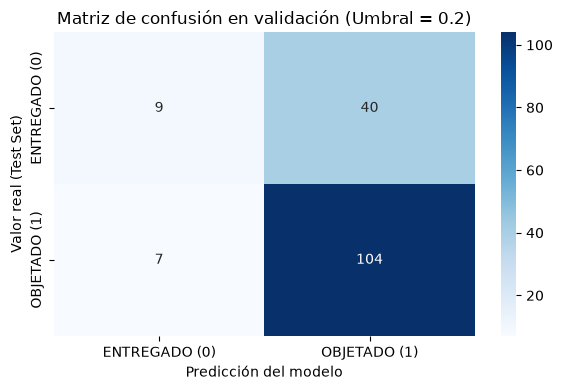

In [25]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ENTREGADO (0)", "OBJETADO (1)"],
    yticklabels=["ENTREGADO (0)", "OBJETADO (1)"],
)
plt.title(f"Matriz de confusión en validación (Umbral = {OPTIMAL_THRESHOLD})")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real (Test Set)")
plt.tight_layout()
plt.show()

Podemos observar un buen número de verdaderos negativos de la variable 'OBJETADO' sobre lo predicho contra el valor real minimizando el número de falsos negativos ideal para el objetivo de la empresa sobre este ítem específico con un valor de 104 sobre 111, y en el otro caso presentando un número medio para los falsos positivos manteniendo la actitud conservadora sobre la duda, de 40 sobre 49.

In [26]:
print("\nReporte de Clasificación con Umbral Calibrado:")
print(classification_report(y_test, preds_test, target_names=["ENTREGADO", "OBJETADO"]))


Reporte de Clasificación con Umbral Calibrado:
              precision    recall  f1-score   support

   ENTREGADO       0.56      0.18      0.28        49
    OBJETADO       0.72      0.94      0.82       111

    accuracy                           0.71       160
   macro avg       0.64      0.56      0.55       160
weighted avg       0.67      0.71      0.65       160



Con un Recall en métrica de 94% podemos evidenciar que se está alcanzando un nivel de sensibilidad alta para la clase 'OBJETADO' la cual es un requerimiento del modelo manteniendo un F1_Score en una métrica favorable de 82%, con un Accuracy de 71% el cual es un poco bajo pero manteniendo dicha actitud conservadora para minimizar los gastos más importantes.

In [27]:
artefactos = {
    "model": model,
    "tfidf_hechos": tfidf_hechos,
    "tfidf_piezas": tfidf_piezas,
    "threshold": OPTIMAL_THRESHOLD,
}

In [29]:
joblib.dump(artefactos, "modelo_subocol_calibrado.joblib")
print("Artefactos exportados exitosamente en 'modelo_subocol_calibrado.joblib'")

Artefactos exportados exitosamente en 'modelo_subocol_calibrado.joblib'


Guardamos los artefactos del modelo para poder utilizarlo en el servicio de inferencia que va a ser consumido por el API que en este caso será asíncrono directamente con la librería FastAPI.